Methods
Data Acquisition
1. Raw signal data was recorded and stored in a proprietary compressed format. For all signals, we provide the standard set of 12 leads (I, II, III, AVL, AVR, AVF, V1, ..., V6) with reference electrodes on the right arm.
2. The corresponding general metadata (such as age, sex, weight and height) was collected in a database.
3. Each record was annotated with a report string (generated by cardiologist or automatic interpretation by ECG-device) which was converted into a standardized set of SCP-ECG statements (scp_codes). For most records also the heart’s axis (heart_axis) and infarction stadium (infarction_stadium1 and infarction_stadium2, if present) were extracted.
4. A large fraction of the records was validated by a second cardiologist.
5. All records were validated by a technical expert focusing mainly on signal characteristics.

Data Preprocessing
ECGs and patients are identified by unique identifiers (ecg_id and patient_id). Personal information in the metadata, such as names of validating cardiologists, nurses and recording site (hospital etc.) of the recording was pseudonymized. The date of birth only as age at the time of the ECG recording, where ages of more than 89 years appear in the range of 300 years in compliance with HIPAA standards. Furthermore, all ECG recording dates were shifted by a random offset for each patient. The ECG statements used for annotating the records follow the SCP-ECG standard [3]

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

 3.16.drawio
 7.19.drawio
 7.1.drawio
'Argument questions.gdoc'
 C.gdoc
'Chemistry Unit-01 Notes.gdoc'
'Chemistry Unit-03 Notes (1).gdoc'
'Chemistry Unit-03 Notes.gdoc'
'Chemistry Unit-04 Notes.gdoc'
'Chemistry Unit-05 Notes.gdoc'
 Classroom
'Colab Notebooks'
'Completion Certificate _ SkillsBuild.pdf'
'Concept Note for Category 2.pdf'
'DocScanner May 1, 2026 7-22 AM.pdf'
 ECG_dataset
'logic gate and switching circuit.gdoc'
'Mathematical logic.gdoc'
 melb_data.gsheet
"Myshkin: Analysis of Dostoevsky's Idiot.gdoc"
'Normal form.gdoc'
'phy assignment.pdf'
'Screen Recording 2024-12-05 220552.mp4'
'The Fluidity of Identity.docx'
'WhatsApp Image 2026-04-28 at 5.55.08 PM.jpeg'
'WhatsApp Image 2026-05-01 at 10.32.03 PM.jpeg'
'WhatsApp Image 2026-05-01 at 10.39.45 PM.jpeg'


In [3]:
!unzip "/content/drive/MyDrive/ECG_dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1.zip" -d "/content/PTB-XL"

Streaming output truncated to the last 5000 lines.
  inflating: /content/PTB-XL/records500/19000/19338_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19339_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19339_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19340_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19340_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19341_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19341_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19342_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19342_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19343_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19343_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19344_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19344_hr.hea  
  inflating: /content/PTB-XL/records500/19000/19345_hr.dat  
  inflating: /content/PTB-XL/records500/19000/19345_hr.hea  
  inflating: /content/PTB-XL/recor

My Drive/
└── ECG_dataset/
    └── ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1.zip
    

In [4]:
!ls "/content/PTB-XL"

example_physionet.py  ptbxl_database.csv  records100  scp_statements.csv
LICENSE.txt	      RECORDS		  records500  SHA256SUMS.txt


In [5]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
import pandas as pd

df = pd.read_csv("/content/PTB-XL/ptbxl_database.csv")

df.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [7]:
df.columns

Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='object')

In [8]:
df.isna().sum()

,0
ecg_id,0
patient_id,0
age,89
sex,0
height,14854
weight,12408
nurse,1509
site,18
device,0
recording_date,0


In [9]:
df.shape

(21837, 28)

In [10]:
df.iloc[0]

,0
ecg_id,1
patient_id,15709.0
age,56.0
sex,1
height,NaN
weight,63.0
nurse,2.0
site,0.0
device,CS-12 E
recording_date,1984-11-09 09:17:34


In [11]:
!pip install wfdb==4.1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 12.9 MB/s eta 0:00:00


In [12]:
import pandas as pd
print(pd.__version__)

2.2.2


In [13]:
try:
    import wfdb
    print("wfdb version:", wfdb.__version__)
except Exception as e:
    print(e)

wfdb version: 4.1.2


In [14]:
import wfdb
import os

# Base directory where the PTB-XL data was unzipped
data_base_path = "/content/PTB-XL"

# Get a record name that is known to exist from the unzipping output.
# For example, records500/19000/19338_hr was mentioned in the truncated output.
# We find the corresponding entry in the dataframe. ecg_id 19338 corresponds to index 19337.
record_to_load_index = 19337  # Corresponds to ecg_id = 19338
record_name_relative = df.iloc[record_to_load_index]['filename_hr']  # Use filename_hr for a known existing file

# Construct the full path by joining the base path with the relative filename.
# wfdb.rdsamp expects the record name *without* the extension.
full_record_path = os.path.join(data_base_path, record_name_relative)

# Use wfdb.rdsamp to read the record
record = wfdb.rdsamp(full_record_path)

signal = record[0]
metadata = record[1]

print(f"Successfully loaded record: {full_record_path}")
print(f"Signal shape: {signal.shape}")
print(f"Metadata keys: {metadata.keys()}")

Successfully loaded record: /content/PTB-XL/records500/19000/19338_hr
Signal shape: (5000, 12)
Metadata keys: dict_keys(['fs', 'sig_len', 'n_sig', 'base_date', 'base_time', 'units', 'sig_name', 'comments'])


                ECG (.dat/.hea)
                      │
                      ▼
            Signal preprocessing
                      │
                      ▼
            Feature extraction
                      │
                      ▼
          Machine Learning model(s)
                      │
                      ▼
        Clinical interpretation layer
                      │
                      ▼
          Automatically generated report

Let's interpret it.

5000 = time samples
12 = the 12 ECG leads (I, II, III, aVR, aVL, aVF, V1–V6)

Since this is records500, the recording is sampled at 500 Hz.

That means:

Sampling frequency = 500 samples/second
Recording duration = 5000 / 500 = 10 seconds [10-second ECG
        ->
5000 timestamps
        ->
12 measurements at each timestamp]

==================================================
data visualization


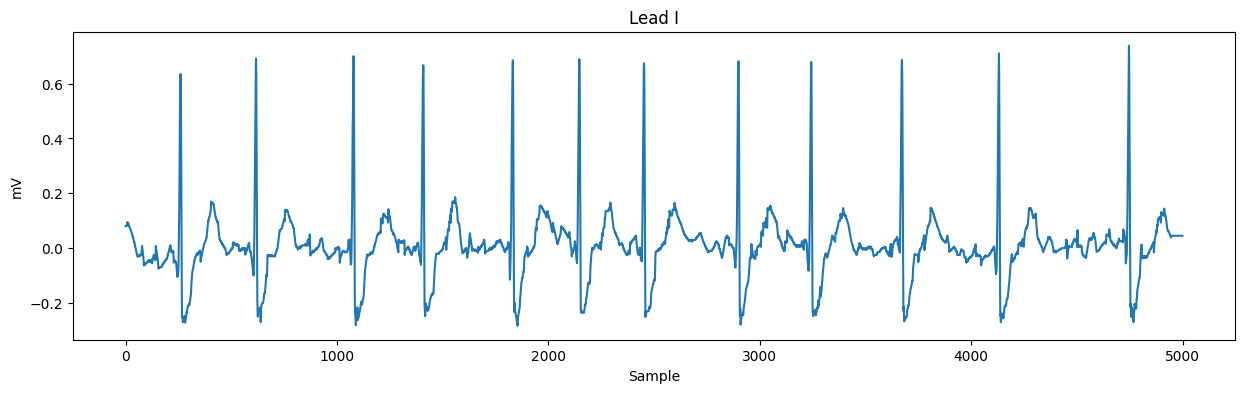

In [15]:
#==================================================================
# plotting a single sample example of the dataset [ecg_id = 19338]
#==================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(signal[:,0])      # Lead I
plt.title("Lead I")
plt.xlabel("Sample")
plt.ylabel("mV")
plt.show()

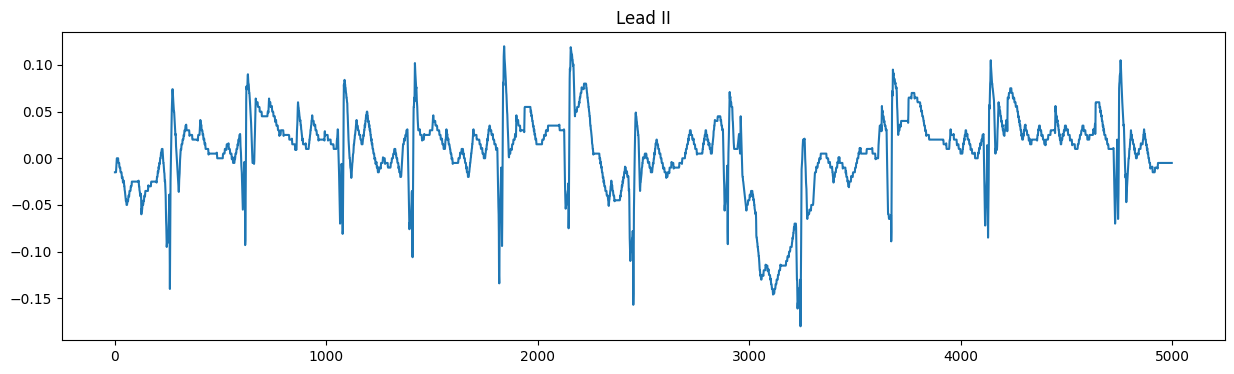

In [16]:
plt.figure(figsize=(15,4))
plt.plot(signal[:,1])      # Lead II
plt.title("Lead II")
plt.show()

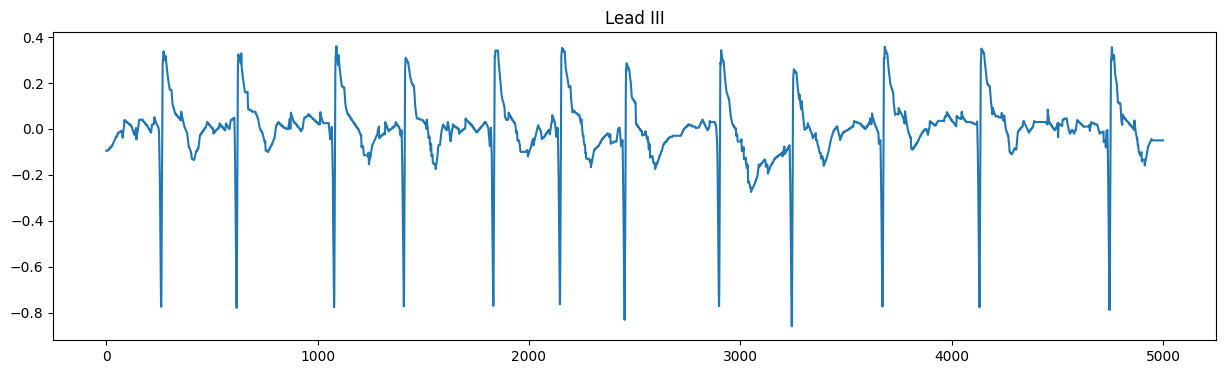

In [17]:
plt.figure(figsize=(15,4))
plt.plot(signal[:,2])      # Lead III
plt.title("Lead III")
plt.show()

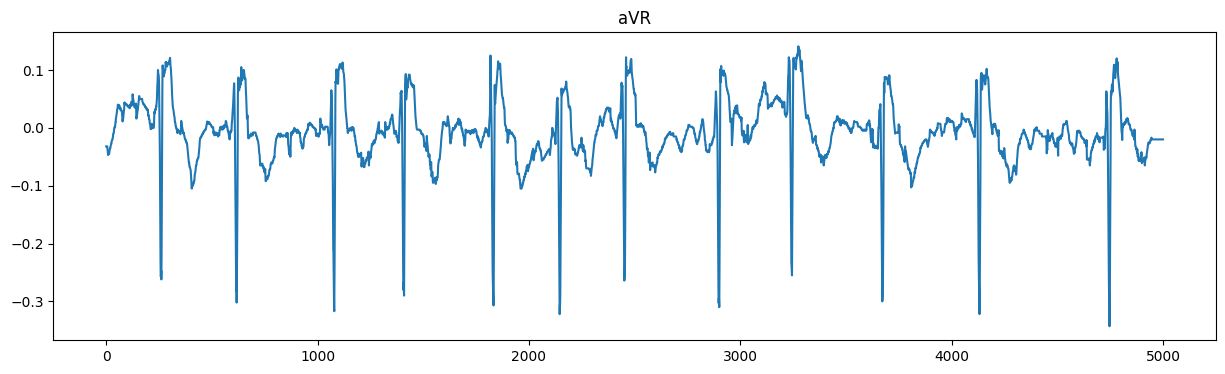

In [18]:
plt.figure(figsize=(15,4))
plt.plot(signal[:,3])      # aVR
plt.title("aVR")
plt.show()

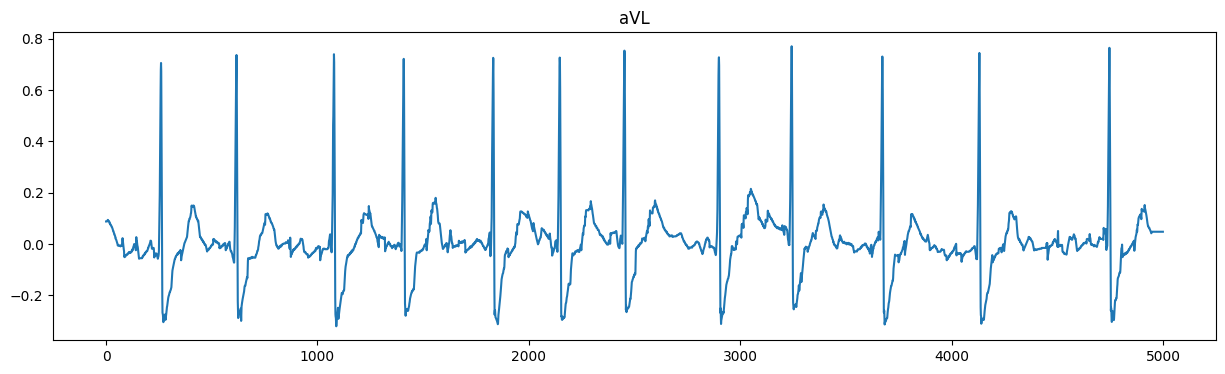

In [19]:

plt.figure(figsize=(15,4))
plt.plot(signal[:,4])      # aVL
plt.title("aVL")
plt.show()

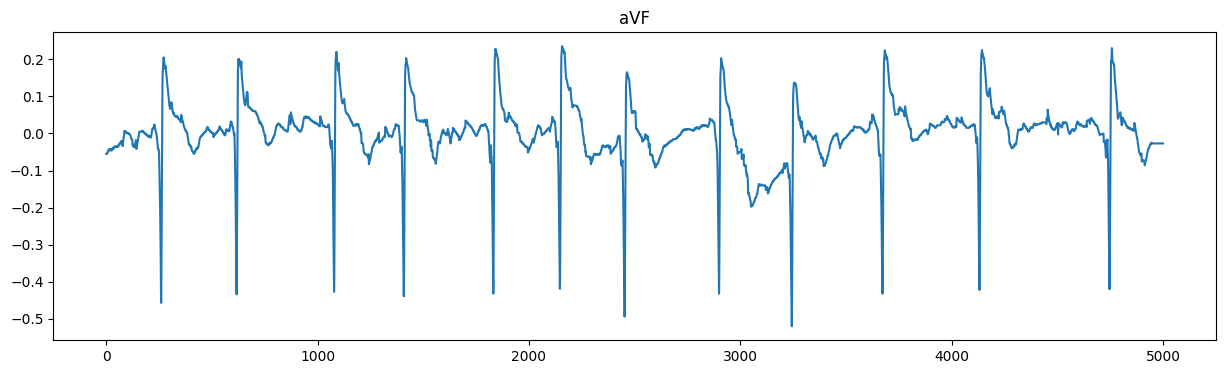

In [20]:

plt.figure(figsize=(15,4))
plt.plot(signal[:,5])      # aVF
plt.title("aVF")
plt.show()

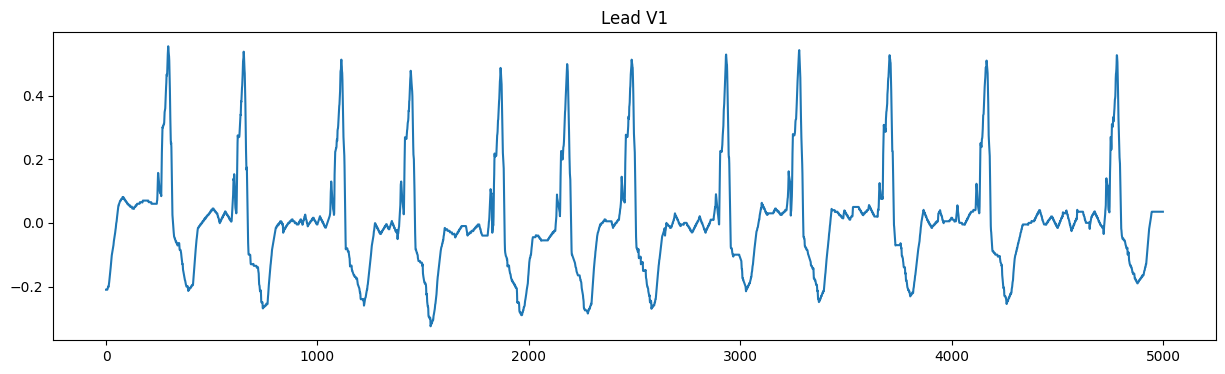

In [21]:
 plt.figure(figsize=(15,4))
plt.plot(signal[:,6])      # Lead V1
plt.title("Lead V1")
plt.show()

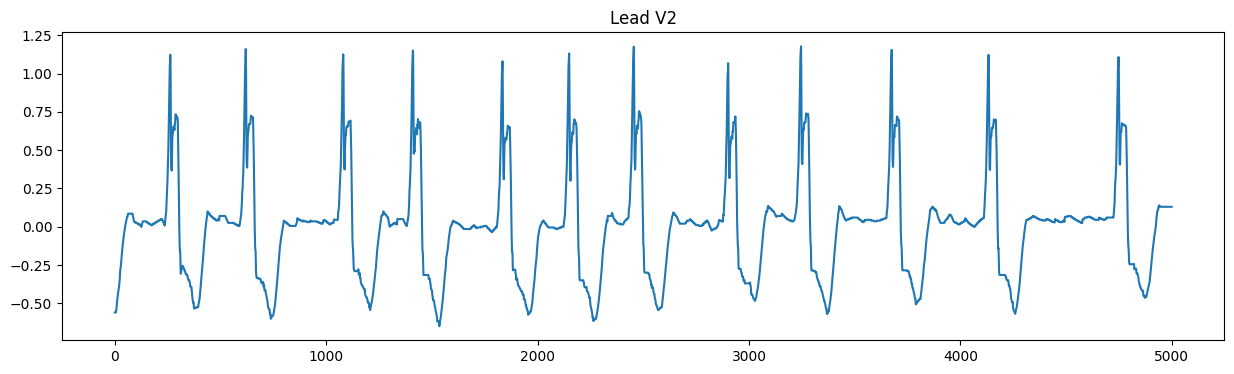

In [22]:
 plt.figure(figsize=(15,4))
plt.plot(signal[:,7])      # Lead V2
plt.title("Lead V2")
plt.show()

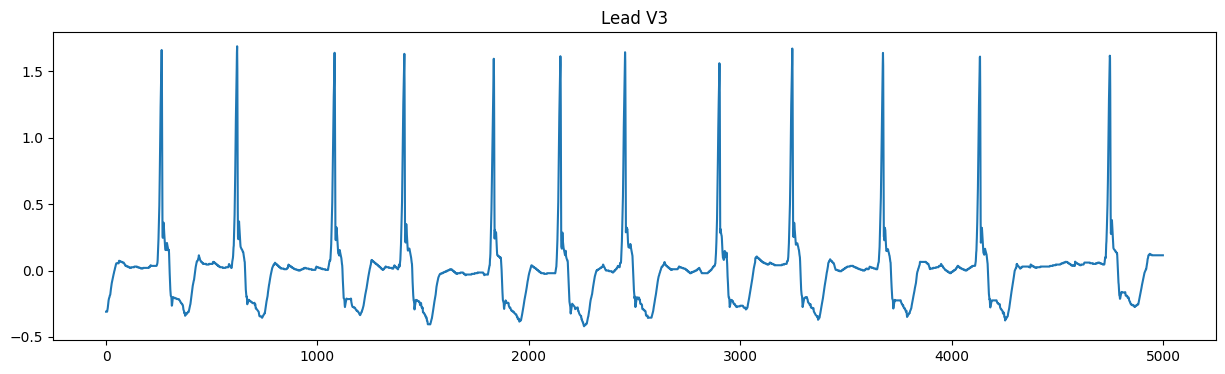

In [23]:
  plt.figure(figsize=(15,4))
plt.plot(signal[:,8])      # Lead V3
plt.title("Lead V3")
plt.show()

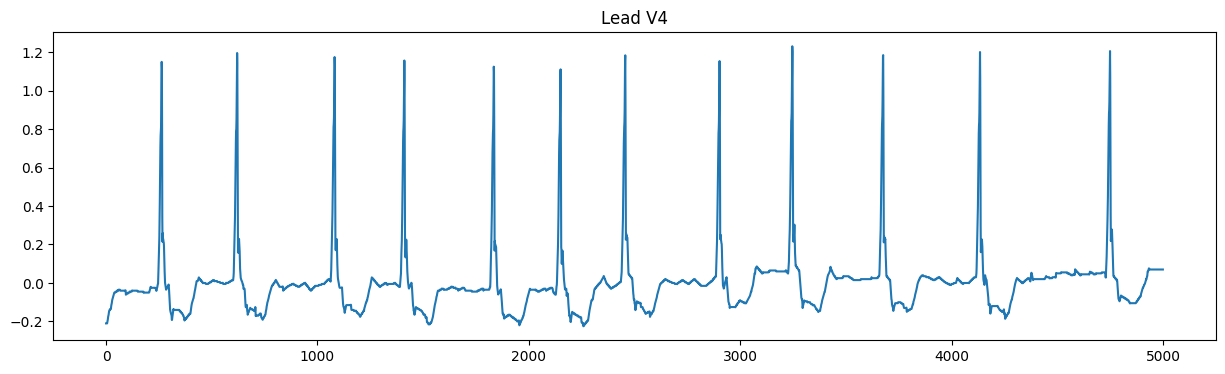

In [24]:
 plt.figure(figsize=(15,4))
plt.plot(signal[:,9])      # Lead V4
plt.title("Lead V4")
plt.show()

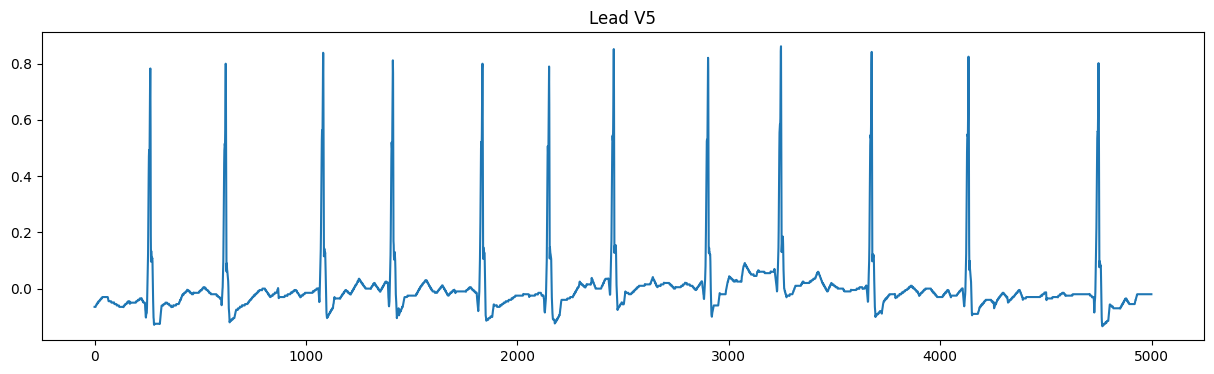

In [25]:
  plt.figure(figsize=(15,4))
plt.plot(signal[:,10])      # Lead V5
plt.title("Lead V5")
plt.show()

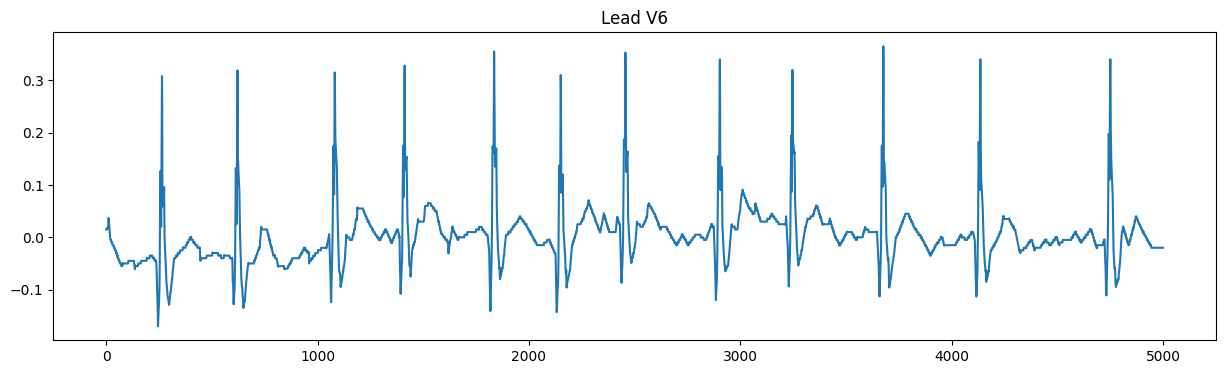

In [26]:
  plt.figure(figsize=(15,4))
plt.plot(signal[:,11])      # Lead V6
plt.title("Lead V6")
plt.show()

In [27]:
da = pd.DataFrame(signal)

In [28]:
da.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.08,-0.015,-0.095,-0.032,0.088,-0.055,-0.21,-0.56,-0.31,-0.21,-0.065,0.015
1,0.08,-0.015,-0.095,-0.032,0.088,-0.055,-0.21,-0.56,-0.31,-0.21,-0.065,0.015
2,0.08,-0.015,-0.095,-0.032,0.088,-0.055,-0.21,-0.56,-0.31,-0.21,-0.065,0.015
3,0.08,-0.015,-0.095,-0.032,0.088,-0.055,-0.21,-0.56,-0.31,-0.21,-0.065,0.015
4,0.08,-0.015,-0.095,-0.032,0.088,-0.055,-0.21,-0.56,-0.31,-0.21,-0.065,0.015


In [29]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=da)

https://docs.google.com/spreadsheets/d/1tzyrdfIK_fGLJNiq2JlUeP-GvPlZW_C_bM8UtjiV7dQ/edit#gid=0


In [30]:
signal[0]

array([ 0.08 , -0.015, -0.095, -0.032,  0.088, -0.055, -0.21 , -0.56 ,
       -0.31 , -0.21 , -0.065,  0.015])

In [31]:
signal[:,0]

array([0.08 , 0.08 , 0.08 , ..., 0.045, 0.045, 0.045])

In [32]:
#==================================================
# DATASET OVERVIEW: EXPLORATORY DATA ANALYSIS (EDA)
#==================================================
#todo: adding visulalizaiton plots
# Dataset dimensions
print(f"Total ECG recordings : {df.shape[0]}")
print(f"Total attributes     : {df.shape[1]}")

# Unique patients
print(f"Unique patients      : {df['patient_id'].nunique()}")

# Age statistics
print("\nAge Distribution")
print(df['age'].describe())

# Sex distribution
print("\nSex Distribution")
print(df['sex'].value_counts(dropna=False))

# Missing values
print("\nMissing Values")
print(df.isnull().sum().sort_values(ascending=False))

# Diagnosis labels (raw SCP codes)
print("\nExample Diagnosis Labels (SCP Codes)")
print(df['scp_codes'].head())

print("\nNumber of unique SCP code combinations:")
print(df['scp_codes'].nunique())


Total ECG recordings : 21837
Total attributes     : 28
Unique patients      : 18885

Age Distribution
count    21748.000000
mean        59.836307
std         16.953125
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max         95.000000
Name: age, dtype: float64

Sex Distribution
sex
0    11379
1    10458
Name: count, dtype: int64

Missing Values
electrodes_problems             21807
infarction_stadium2             21734
pacemaker                       21544
burst_noise                     21224
baseline_drift                  20230
extra_beats                     19883
static_noise                    18575
infarction_stadium1             16211
height                          14854
weight                          12408
validated_by                     9411
heart_axis                       8505
nurse                            1509
age                                89
site                               18
recording_date                      0
pa

(array([   8.,   13.,   43.,  506.,  402.,  409.,  616.,  852.,  889.,
        1288., 1720., 2056., 2520., 2657., 1980., 2153., 1669., 1106.,
         746.,  115.]),
 array([ 2.  ,  6.65, 11.3 , 15.95, 20.6 , 25.25, 29.9 , 34.55, 39.2 ,
        43.85, 48.5 , 53.15, 57.8 , 62.45, 67.1 , 71.75, 76.4 , 81.05,
        85.7 , 90.35, 95.  ]),
 <BarContainer object of 20 artists>)

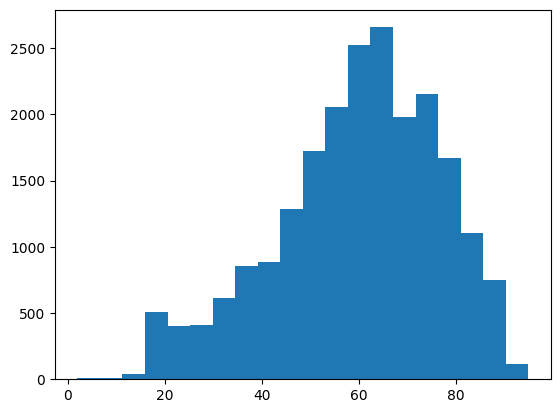

In [33]:
plt.hist(df["age"].dropna(), bins=20)
#todo labeling

The age distribution is centred around older adults (median ≈ 62 years), with the majority of patients between approximately 40 and 80 years of age. Very few paediatric cases are present, indicating that PTB-XL predominantly contains adult ECG recordings.

<Axes: xlabel='sex'>

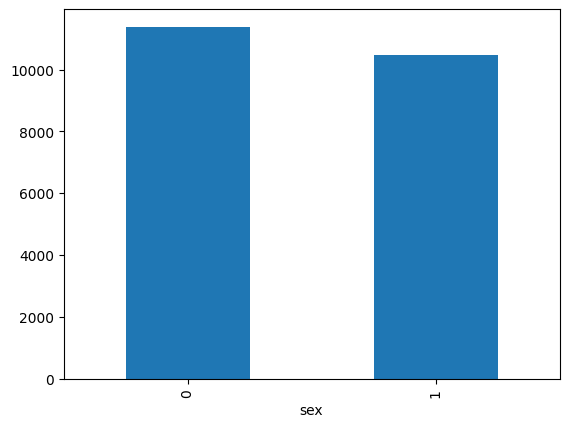

In [34]:

df["sex"].value_counts().plot(kind="bar")
#todo labeling

The dataset has a nearly balanced sex distribution, reducing the likelihood of significant sex-related sampling bias.

<Axes: >

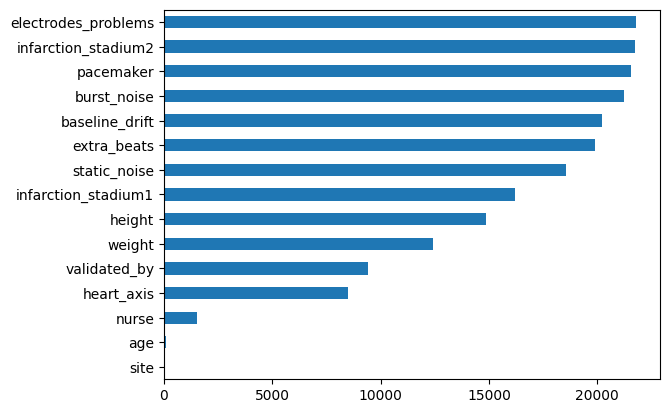

In [35]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()
#todo labeling
missing.plot(kind="barh")

Most missing values occur in optional clinical metadata (e.g., infarction stage, pacemaker status, baseline drift, electrode problems, height, and weight). The essential fields required for ECG analysis—including ECG identifiers, patient identifiers, SCP diagnostic codes, and signal file paths—are complete, allowing signal-based analysis without major preprocessing issues.

In [36]:
#Convert the string into a Python dictionary.
import ast

df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

In [37]:
from collections import Counter

scp_counter = Counter()

for codes in df["scp_codes"]:
    scp_counter.update(codes.keys())

In [38]:
import pandas as pd

scp_df = (
    pd.DataFrame(scp_counter.items(),
                 columns=["Diagnosis", "Count"])
      .sort_values("Count", ascending=False)
)
scp_df.head(20)

,Diagnosis,Count
2,SR,16782
0,NORM,9528
5,ABQRS,3327
4,IMI,2685
21,ASMI,2363
12,LVH,2137
9,NDT,1829
15,LAFB,1626
8,AFIB,1514
26,ISC_,1275


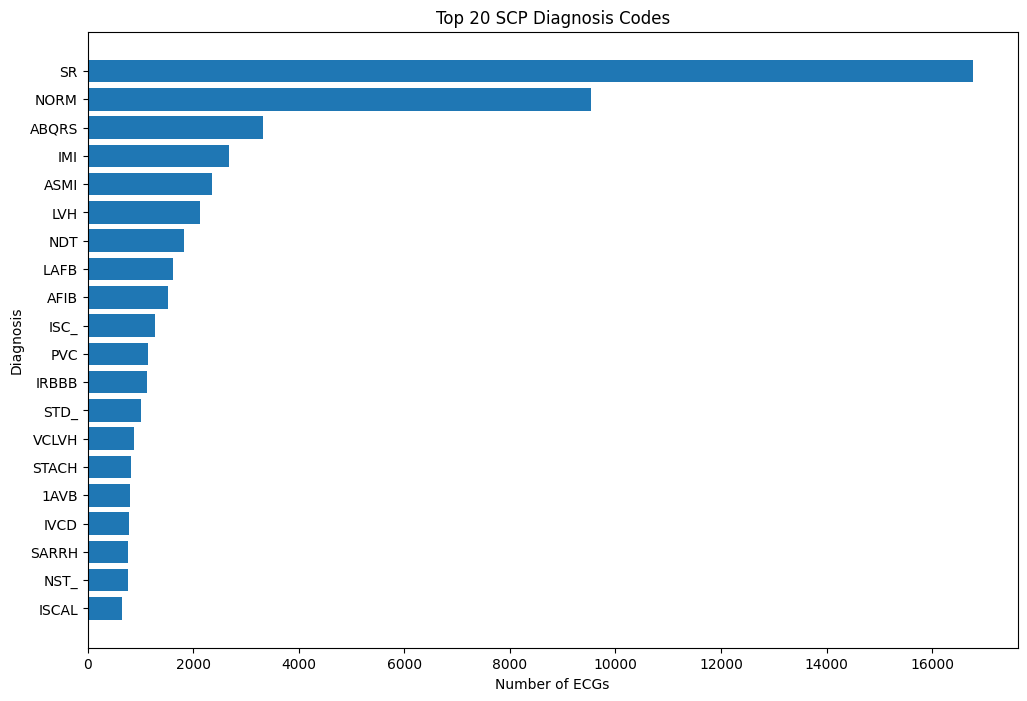

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    scp_df["Diagnosis"][:20],
    scp_df["Count"][:20]
)

plt.gca().invert_yaxis()

plt.xlabel("Number of ECGs")
plt.ylabel("Diagnosis")
plt.title("Top 20 SCP Diagnosis Codes")

plt.show()

Sinus Rhythm dominates the dataset indicating majority of patients have normal sinus rythem even if they have other abnormalities. The second dominating factor is norm: interpreting that overall ecg is normal for a large portion of  patients providing a balance between healthy and unhealthy individuals.  ABQRS being common and in general stuctural diagnosis appear more frequent than rythmic diagnosis [data-imbalance to be considered during training]

| Category                  | Example SCP codes               | Meaning                                                                                                 |
| ------------------------- | ------------------------------- | ------------------------------------------------------------------------------------------------------- |
| **Normal**                | NORM                            | Normal ECG                                                                                              |
| **Rhythm abnormalities**  | AFIB, AFLT, SBRAD, STACH, SVTAC | Atrial fibrillation, atrial flutter, sinus bradycardia, sinus tachycardia, supraventricular tachycardia |
| **Conduction disorders**  | LBBB, RBBB, AVB, LAFB           | Bundle branch blocks, AV block, fascicular block                                                        |
| **Myocardial infarction** | IMI, AMI, PMI, ASMI             | Different infarction locations                                                                          |
| **Hypertrophy**           | LVH, RVH                        | Left/right ventricular hypertrophy                                                                      |
| **ST-T abnormalities**    | STTC, NST_, ISCA                | ST-segment and T-wave changes                                                                           |


clustering...
required for classification

count    21837.000000
mean         2.798873
std          1.211410
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          9.000000
Name: scp_codes, dtype: float64


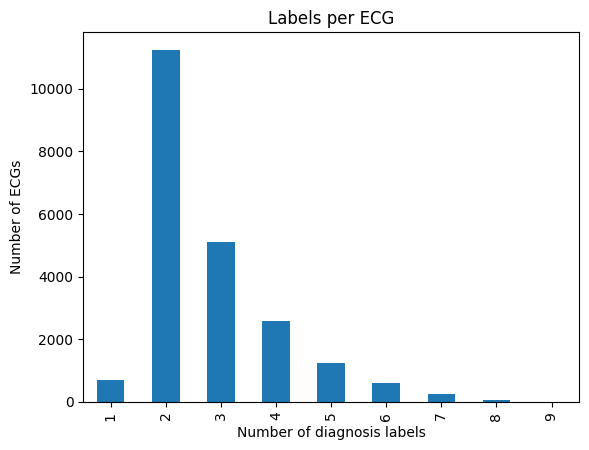

In [40]:
# Multi-label sigmoid output: Count labels in each ECG
label_count = df["scp_codes"].apply(len)

print(label_count.describe())

label_count.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of diagnosis labels")
plt.ylabel("Number of ECGs")
plt.title("Labels per ECG")
plt.show()

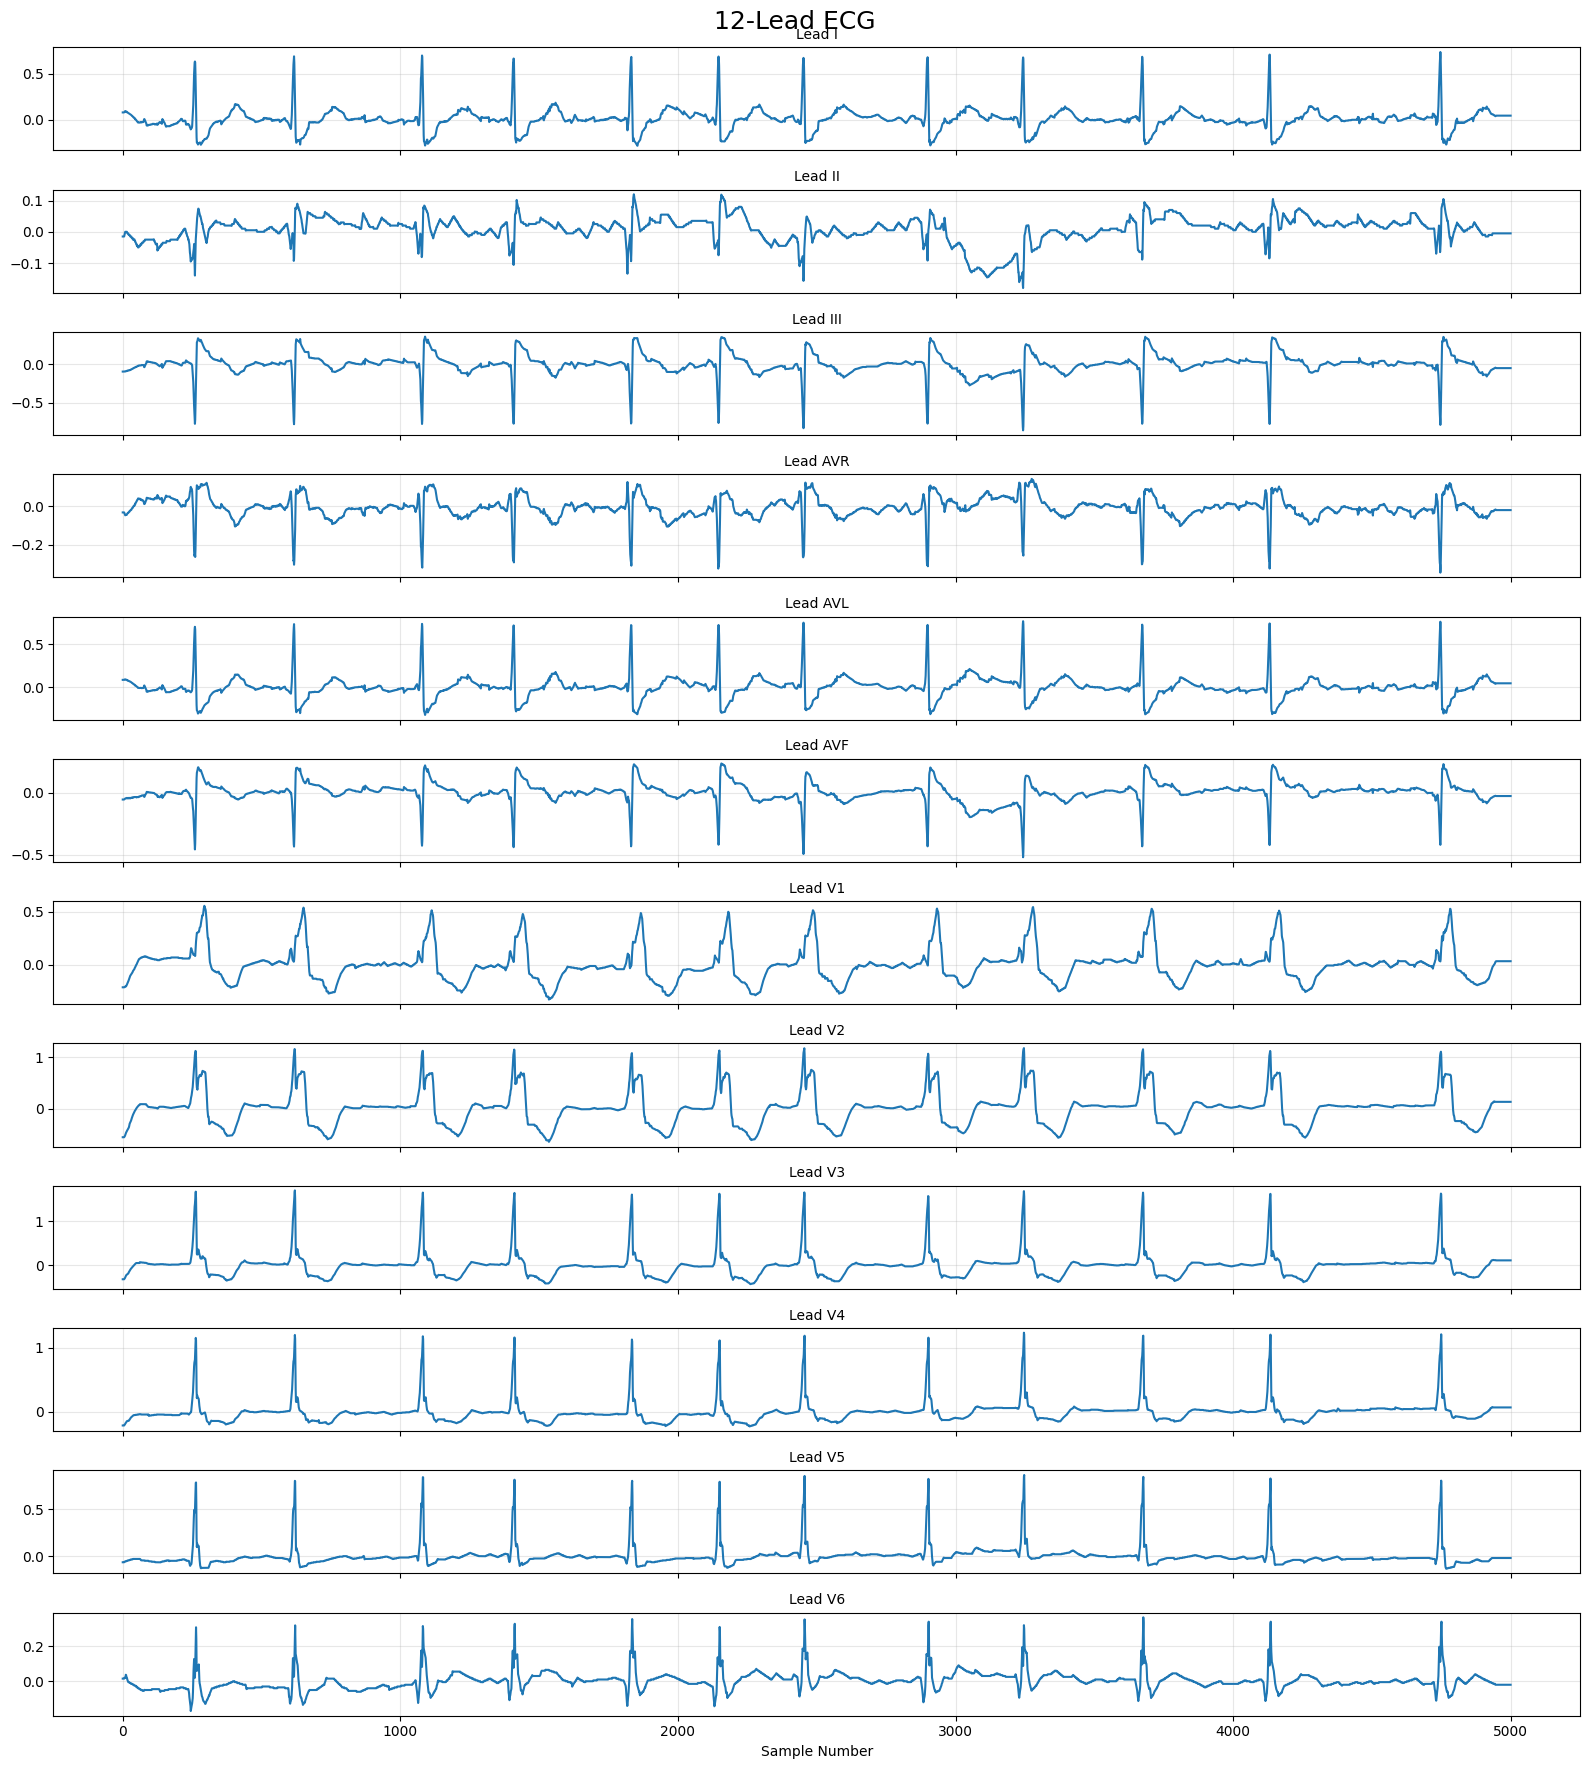

In [41]:
import matplotlib.pyplot as plt

lead_names = metadata['sig_name']

fig, axes = plt.subplots(
    nrows=12,
    ncols=1,
    figsize=(16,18),
    sharex=True
)

for i, ax in enumerate(axes):
    ax.plot(signal[:, i])
    ax.set_title(f"Lead {lead_names[i]}", fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Sample Number")

plt.suptitle("12-Lead ECG", fontsize=18)
plt.tight_layout()
plt.show()

In [42]:
scp = pd.read_csv("/content/PTB-XL/scp_statements.csv")

print(scp.columns)
scp.head()

Index(['Unnamed: 0', 'description', 'diagnostic', 'form', 'rhythm',
       'diagnostic_class', 'diagnostic_subclass', 'Statement Category',
       'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code',
       'DICOM Code'],
      dtype='object')


,Unnamed: 0,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
0,NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
1,NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
2,DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
3,LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
4,NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [43]:
import ast

scp = pd.read_csv("/content/PTB-XL/scp_statements.csv", index_col=0)

scp.head()

,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7


In [44]:
diagnostic = scp[scp["diagnostic"] == 1]

print(diagnostic[["description", "diagnostic_class"]].head())

                          description diagnostic_class
NDT    non-diagnostic T abnormalities             STTC
NST_          non-specific ST changes             STTC
DIG                  digitalis-effect             STTC
LNGQT                long QT-interval             STTC
NORM                       normal ECG             NORM


In [45]:
diagnostic_map = diagnostic["diagnostic_class"].to_dict()

print(diagnostic_map)

{'NDT': 'STTC', 'NST_': 'STTC', 'DIG': 'STTC', 'LNGQT': 'STTC', 'NORM': 'NORM', 'IMI': 'MI', 'ASMI': 'MI', 'LVH': 'HYP', 'LAFB': 'CD', 'ISC_': 'STTC', 'IRBBB': 'CD', '1AVB': 'CD', 'IVCD': 'CD', 'ISCAL': 'STTC', 'CRBBB': 'CD', 'CLBBB': 'CD', 'ILMI': 'MI', 'LAO/LAE': 'HYP', 'AMI': 'MI', 'ALMI': 'MI', 'ISCIN': 'STTC', 'INJAS': 'MI', 'LMI': 'MI', 'ISCIL': 'STTC', 'LPFB': 'CD', 'ISCAS': 'STTC', 'INJAL': 'MI', 'ISCLA': 'STTC', 'RVH': 'HYP', 'ANEUR': 'STTC', 'RAO/RAE': 'HYP', 'EL': 'STTC', 'WPW': 'CD', 'ILBBB': 'CD', 'IPLMI': 'MI', 'ISCAN': 'STTC', 'IPMI': 'MI', 'SEHYP': 'HYP', 'INJIN': 'MI', 'INJLA': 'MI', 'PMI': 'MI', '3AVB': 'CD', 'INJIL': 'MI', '2AVB': 'CD'}


In [46]:
def get_superclasses(scp_dict):
    superclasses = set()

    for code in scp_dict.keys():
        if code in diagnostic_map:
            superclasses.add(diagnostic_map[code])

    return list(superclasses)

In [48]:
df["superclasses"] = df["scp_codes"].apply(get_superclasses)

In [49]:
print(df[["scp_codes", "superclasses"]].head(10))

                                  scp_codes superclasses
0  {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}       [NORM]
1              {'NORM': 80.0, 'SBRAD': 0.0}       [NORM]
2                {'NORM': 100.0, 'SR': 0.0}       [NORM]
3                {'NORM': 100.0, 'SR': 0.0}       [NORM]
4                {'NORM': 100.0, 'SR': 0.0}       [NORM]
5                {'NORM': 100.0, 'SR': 0.0}       [NORM]
6                {'NORM': 100.0, 'SR': 0.0}       [NORM]
7    {'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}         [MI]
8                {'NORM': 100.0, 'SR': 0.0}       [NORM]
9                {'NORM': 100.0, 'SR': 0.0}       [NORM]


In [50]:
from collections import Counter

counter = Counter()

for labels in df["superclasses"]:
    counter.update(labels)

print(counter)

Counter({'NORM': 9528, 'MI': 5486, 'STTC': 5250, 'CD': 4907, 'HYP': 2655})


These are the **five diagnostic superclasses** defined by the PTB-XL authors. Think of them as the broad disease categories your model will predict.

| Superclass | Meaning                                                     | Examples of SCP codes           |
| ---------- | ----------------------------------------------------------- | ------------------------------- |
| **NORM**   | Normal ECG                                                  | NORM                            |
| **MI**     | **Myocardial Infarction** (heart attack)                    | IMI, AMI, ASMI, ALMI, PMI...    |
| **STTC**   | **ST/T Change** (abnormal ST segment or T wave)             | STTC, ISCA, ISCI, NST_...       |
| **CD**     | **Conduction Disturbance** (electrical conduction problems) | LBBB, RBBB, LAFB, LPFB, IVCD... |
| **HYP**    | **Hypertrophy** (enlargement/thickening of heart muscle)    | LVH, RVH, LAO/LAE...            |

---

## What each one means clinically

### 🟢 NORM

The ECG appears clinically normal.

Examples:

* Normal rhythm
* No significant abnormalities

---

### 🔴 MI (Myocardial Infarction)

The ECG shows evidence of a **heart attack**, either current or previous.

Typical findings include:

* ST elevation/depression
* Pathological Q waves
* T-wave inversion

Example SCP codes:

```text
IMI  → Inferior MI
AMI  → Anterior MI
ASMI → Anteroseptal MI
```

---

### 🟠 STTC (ST/T Changes)

These are abnormalities in the **ST segment or T wave**.

They may indicate:

* Ischemia (reduced blood flow)
* Electrolyte imbalance
* Drug effects
* Early signs of cardiac disease

Not every ST/T change means a heart attack.

---

### 🔵 CD (Conduction Disturbance)

The heart's electrical signal is travelling abnormally.

Examples:

* Right Bundle Branch Block (RBBB)
* Left Bundle Branch Block (LBBB)
* Fascicular blocks

These affect **how** the electrical impulse moves through the heart.

---

### 🟣 HYP (Hypertrophy)

The heart muscle is enlarged.

Examples:

* Left Ventricular Hypertrophy (LVH)
* Right Ventricular Hypertrophy (RVH)

Often associated with:

* High blood pressure
* Valve disease
* Cardiomyopathy

---

## Looking at your counts

```text
NORM  9528
MI     5486
STTC   5250
CD     4907
HYP    2655
```

This is actually a **fairly reasonable** distribution. The classes are imbalanced, but not to an extreme degree.

A few observations:

* About **44%** of ECGs are labelled **NORM**, so you have a healthy baseline.
* **MI**, **STTC**, and **CD** each appear in roughly **5,000 ECGs**, giving you a good number of positive examples.
* **HYP** is the least common, but with **2,655 ECGs** it's still well represented.

One important point: **these counts add up to more than 21,837 ECGs** because this is a **multi-label dataset**. A single ECG can contribute to multiple categories. For example:

```text
ECG #123

Superclasses:
✓ MI
✓ STTC
```

This single ECG increases both the **MI** count and the **STTC** count.

---

### This is a good target for your project

These five classes are clinically meaningful, commonly used in PTB-XL research, and are much easier to explain than dozens of individual SCP codes. Once your model predicts these superclasses, your report generator can present them in a structured way and, if you extend the project later, you can add more detailed findings such as rhythm analysis or specific SCP codes.


# FEATURE VECTOR

In [52]:
from scipy.stats import skew, kurtosis
import numpy as np

In [53]:
def extract_features(signal):

    features = []

    # signal shape = (1000,12)

    for lead in range(signal.shape[1]):

        x = signal[:, lead]

        features.extend([
            np.mean(x),
            np.std(x),
            np.min(x),
            np.max(x),
            np.median(x),
            np.var(x),
            np.sqrt(np.mean(x**2)),      # RMS
            skew(x),
            kurtosis(x),
            np.sum(x**2)                 # Energy
        ])

    return np.array(features)

In [54]:
feature_vector = extract_features(signal)

print(feature_vector.shape)

(120,)


In [55]:
print(feature_vector)

[ 8.17580000e-03  1.17529874e-01 -2.83000000e-01  7.38000000e-01
  5.00000000e-03  1.38132713e-02  1.17813900e-01  1.61276685e+00
  9.60498390e+00  6.94005750e+01  6.82540000e-03  4.09557678e-02
 -1.80000000e-01  1.20000000e-01  1.50000000e-02  1.67737491e-03
  4.15206093e-02 -1.19624932e+00  2.63553146e+00  8.61980500e+00
 -1.35480000e-03  1.35075610e-01 -8.60000000e-01  3.60000000e-01
  5.00000000e-03  1.82454205e-02  1.35082404e-01 -1.47672111e+00
  9.20701871e+00  9.12362800e+01 -7.51640000e-03  5.63379812e-02
 -3.43000000e-01  1.41000000e-01 -8.00000000e-03  3.17396813e-03
  5.68371745e-02 -1.26123506e+00  6.37259247e+00  1.61523220e+01
  4.69180000e-03  1.25007741e-01 -3.20000000e-01  7.70000000e-01
 -1.00000000e-03  1.56269352e-02  1.25095756e-01  1.57562274e+00
  9.78517559e+00  7.82447410e+01  2.70100000e-03  8.05169224e-02
 -5.20000000e-01  2.35000000e-01  1.00000000e-02  6.48297480e-03
  8.05622132e-02 -1.28375669e+00  7.39038457e+00  3.24513510e+01
 -9.58200000e-04  1.56056

In [58]:
from concurrent.futures import ProcessPoolExecutor
import numpy as np
import wfdb
import os
from tqdm import tqdm

# Define the helper function for processing a single ECG
def process_ecg(path):
    # data_base_path and extract_features are defined in previous cells
    full_path = os.path.join(data_base_path, path)
    signal, meta = wfdb.rdsamp(full_path)
    return extract_features(signal)

# --- Feature Extraction using Multiprocessing ---
paths = df["filename_lr"].tolist()

# Determine the number of worker processes to use
num_workers = os.cpu_count() # Using os.cpu_count() is generally good practice
# If you prefer a fixed number, you can uncomment and use the line below:
# num_workers = 4

print(f"Starting feature extraction for {len(paths)} ECGs using {num_workers} processes...")

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    X = list(tqdm(
        executor.map(process_ecg, paths),
        total=len(paths),
        desc="Extracting Features"
    ))

X = np.array(X)
print(f"Feature matrix X shape: {X.shape}")

# --- Save the extracted features ---
save_path = "/content/drive/MyDrive/X_features.npy"
np.save(save_path, X)
print(f"Features saved to: {save_path}")

# --- Optional: Load features if already saved (uncomment to use) ---
# Uncomment the following lines if you want to load the saved features
# instead of re-extracting them in subsequent runs.
# print(f"Loading features from: {save_path}")
# X = np.load(save_path)
# print(f"Features loaded, shape: {X.shape}")

Starting feature extraction for 21837 ECGs using 2 processes...


Extracting Features: 100%|██████████| 21837/21837 [07:13<00:00, 50.34it/s]

Feature matrix X shape: (21837, 120)
Features saved to: /content/drive/MyDrive/X_features.npy


In [59]:
print(X.shape)
print(type(X))
print(np.isnan(X).sum())
print(np.isinf(X).sum())

(21837, 120)
<class 'numpy.ndarray'>
2
0


In [61]:
X = np.nan_to_num(X)

In [60]:
print(X.shape)

print("Feature means:")
print(np.mean(X, axis=0)[:10])

print("Feature std:")
print(np.std(X, axis=0)[:10])

(21837, 120)
Feature means:
[-1.84585644e-03  1.41213577e-01 -2.80235060e-01  8.23147823e-01
 -2.72089573e-02  2.37799272e-02  1.42091966e-01  2.83021686e+00
  1.35004788e+01  2.69026990e+01]
Feature std:
[5.58512727e-02 6.19568635e-02 2.13620499e-01 3.60076850e-01
 5.90164294e-02 2.82729774e-02 8.19302888e-02 1.50996903e+00
 8.95308285e+00 2.97009372e+02]


In [62]:
print(np.min(X))
print(np.max(X))

-22.665525287622454
384680.660712


In [63]:
print(np.any(np.isnan(X)))
print(np.any(np.isinf(X)))

False
False


In [64]:
leads = ['I','II','III','aVR','aVL','aVF',
         'V1','V2','V3','V4','V5','V6']

stats = ['Mean','Std','Min','Max','Median',
         'Variance','RMS','Skewness','Kurtosis','Energy']

feature_names = []

for lead in leads:
    for stat in stats:
        feature_names.append(f"{lead}_{stat}")

In [67]:
np.save("/content/drive/MyDrive/X.npy", X)
#np.save("/content/drive/MyDrive/Y.npy", Y)

In [66]:
import pickle

with open("/content/drive/MyDrive/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

In [69]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(df["superclasses"])

In [70]:
print(Y.shape)
print(mlb.classes_)

(21837, 5)
['CD' 'HYP' 'MI' 'NORM' 'STTC']


In [71]:
target_names = mlb.classes_
print(classification_report(
    Y_test,
    predictions,
    target_names=target_names
))

NameError: name 'classification_report' is not defined

In [68]:
train_idx = df["strat_fold"] <= 8
val_idx   = df["strat_fold"] == 9
test_idx  = df["strat_fold"] == 10

X_train = X[train_idx]
X_val   = X[val_idx]
X_test  = X[test_idx]

Y_train = Y[train_idx]
Y_val   = Y[val_idx]
Y_test  = Y[test_idx]

NameError: name 'Y' is not defined